# CLASS Mode Evolution Example

This notebook installs CLASS in Google Colab, computes scalar perturbations for selected Fourier modes, prints the matter-radiation equality scale `k_eq`, and plots the Newtonian potential `Phi` and photon density perturbation `delta_gamma`.

The perturbations are initialized early using:

```text
start_large_k_at_tau_h_over_tau_k = 1e-6
```

In [ ]:
# Install build tools and CLASS. This cell can take a few minutes in Colab.
!apt-get -qq update
!apt-get -qq install -y build-essential gfortran git
!pip -q install cython numpy matplotlib

![ -d class_public ] || git clone --depth 1 https://github.com/lesgourg/class_public.git
%cd /content/class_public
!make -j2
!pip -q install .

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Cloning into 'class_public'...
remote: Enumerating objects: 326, done.
remote: Counting objects: 100% (326/326), done.
remote: Compressing objects: 100% (278/278), done.
remote: Total 326 (delta 45), reused 196 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (326/326), 7.63 MiB | 12.06 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/class_public
if ! [ -e /content/class_public/build ]; then mkdir /content/class_public/build ; mkdir /content/class_public/build/lib; fi;
touch build/.base
cd /content/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/content/class_public"' -DHYREC -I../include -I../external/RecfastCLASS -I../external/heating -I../external/HyRec2020 -I../external/Halofit -I../external/HMcode -c ../tools/growTable.c -o growTable.o
cd /content/class_publ

## Compute Perturbations

CLASS returns perturbations as a list, one entry for each requested `k_output_values`. In Newtonian gauge, the potential is stored as `phi`, and the photon density perturbation is stored as `delta_g`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from classy import Class

# Requested modes in Mpc^-1.
k_values = [0.01, 0.2]

# Planck-like flat LCDM parameters.
params = {
    "output": "tCl,mPk,dTk",
    "modes": "s",
    "ic": "ad",
    "gauge": "newtonian",
    "h": 0.6736,
    "omega_b": 0.02237,
    "omega_cdm": 0.1200,
    "A_s": 2.100e-9,
    "n_s": 0.9649,
    "tau_reio": 0.0544,
    "T_cmb": 2.7255,
    "N_ur": 3.046,
    "k_pivot": 0.05,
    "P_k_max_1/Mpc": 1.0,
    "k_output_values": ", ".join(str(k) for k in k_values),
    "start_large_k_at_tau_h_over_tau_k": 1.0e-6,
    "perturbations_sampling_stepsize": 0.05,
    "radiation_streaming_trigger_tau_over_tau_k": 45.0,
    "radiation_streaming_approximation": 3,
    "l_max_g": 50,
    "l_max_pol_g": 50,
    "perturbations_sampling_stepsize": 0.02,
}

cosmo = Class()
cosmo.set(params)
cosmo.compute()

In [ ]:
perturbations = cosmo.get_perturbations()["scalar"]
background = cosmo.get_background()
derived = cosmo.get_current_derived_parameters(["z_eq","z_star"])

z_eq = derived["z_eq"]
z_star = derived["z_star"]

# CLASS gives H(z) in 1/Mpc. The comoving Hubble scale is aH = H/(1+z),
# so k_eq = a_eq H_eq = H(z_eq)/(1+z_eq).
order = np.argsort(background["z"])
z_sorted = background["z"][order]
H_sorted = background["H [1/Mpc]"][order]
H_of_z = interp1d(z_sorted, H_sorted, bounds_error=False, fill_value="extrapolate")
k_eq = float(H_of_z(z_eq) / (1.0 + z_eq))
k_star = float(H_of_z(z_star) / (1.0 + z_star))

R = 3./4.*background['(.)rho_b'][order]/background['(.)rho_g'][order]
rs = background['comov.snd.hrz.'][order]
tau = background['conf. time [Mpc]'][order]

print(f"z_eq = {z_eq:.3f}")
print(f"k_eq = {k_eq:.6g} Mpc^-1")
print(f"##################")
print(f"z_star = {z_star:.3f}")
print(f"k_star = {k_star:.6g} Mpc^-1")

z_eq = 3401.961
k_eq = 0.0103832 Mpc^-1
##################
z_star = 1085.127
k_star = 0.00476408 Mpc^-1


In [ ]:
background.keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'Omega_r(z)', 'Omega_m(z)', 'gr.fac. D', 'gr.fac. f'])

## Plot Mode Evolution

The horizontal axis is the scale factor `a`. The plotted quantities are dimensionless perturbation variables from CLASS.

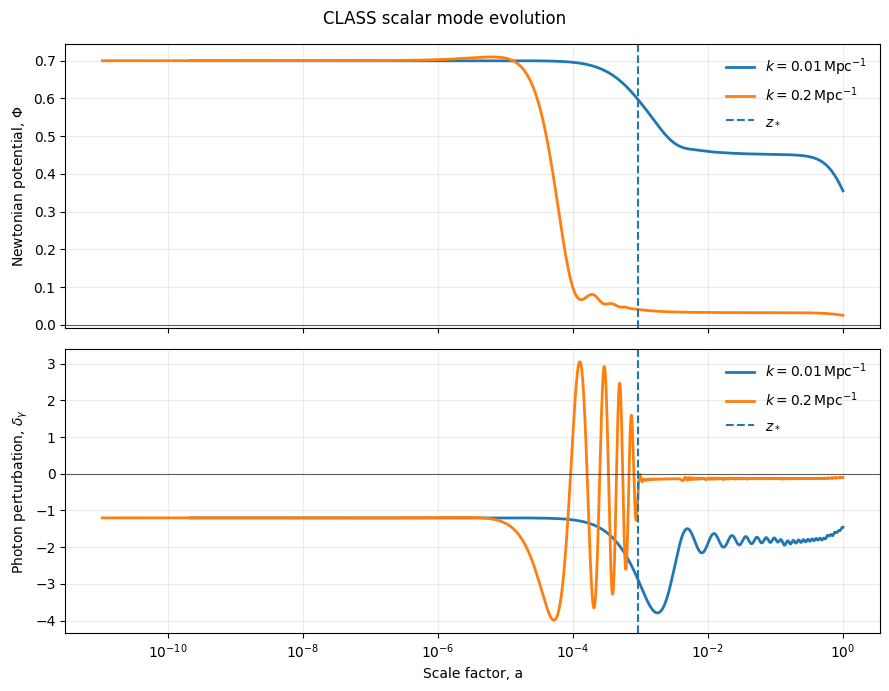

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for k, mode in zip(k_values, perturbations):
    a = mode["a"]
    phi = mode["phi"]
    phi_i = phi[-1]
    delta_gamma = mode["delta_g"]

    keep = (a > 0) & np.isfinite(phi) & np.isfinite(delta_gamma)
    label = rf"$k = {k:g}\,{{\rm Mpc}}^{{-1}}$"

    axes[0].plot(a[keep], phi[keep], lw=2.0, label=label)
    axes[1].plot(a[keep], delta_gamma[keep], lw=2.0, label=label)

axes[0].set_ylabel(r"Newtonian potential, $\Phi$")
axes[1].set_ylabel(r"Photon perturbation, $\delta_\gamma$")
axes[1].set_xlabel("Scale factor, a")

for ax in axes:
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=0.8, alpha=0.6)
    ax.grid(True, which="both", alpha=0.25)
    ax.axvline(x=1/(z_star+1),linestyle='--',label=r'$z_*$')
    ax.legend(frameon=False)

fig.suptitle("CLASS scalar mode evolution")
fig.tight_layout()
plt.show()

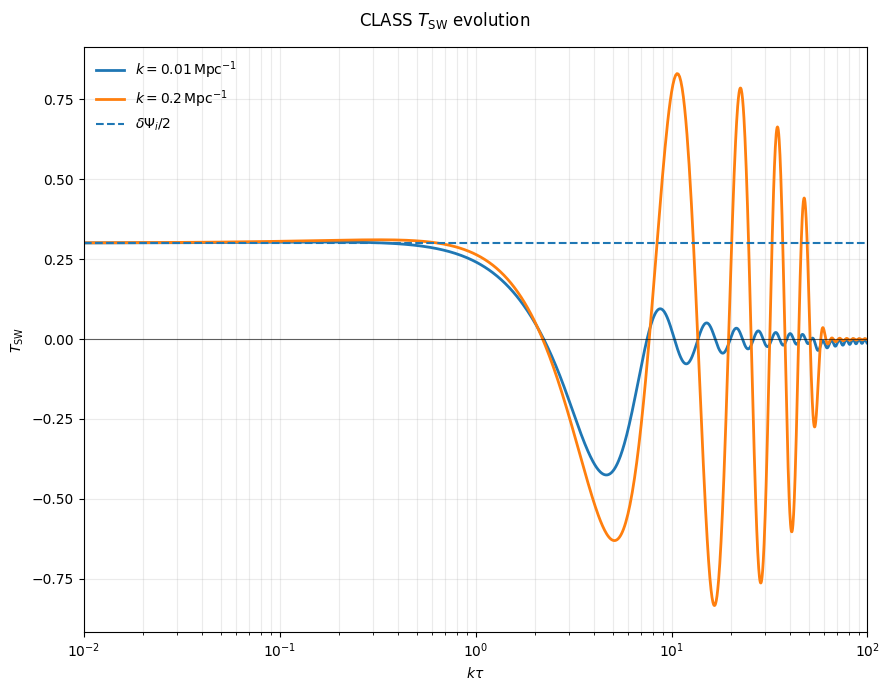

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(9, 7), sharex=True)

for k, mode in zip(k_values, perturbations):
    a = mode["a"]
    tau = mode["tau [Mpc]"]
    psi = mode["psi"]
    delta_gamma = mode["delta_g"]

    label = rf"$k = {k:g}\,{{\rm Mpc}}^{{-1}}$"

    axes.plot(k*tau, delta_gamma/4+psi, lw=2.0, label=label)

# psi_i = perturbations[1]["psi"][0]
# x = k_values[1]*perturbations[1]["tau [Mpc]"]

# T_SW_rad = - psi_i * 3 * (
#         x * (-24 + x**2) * np.cos(x / np.sqrt(3))- 4 * np.sqrt(3) *
#          (-6 + x**2) * np.sin(x / np.sqrt(3)))/(2 * x**3)

axes.plot(x, R lw=2.0, label='RD analytic')

psi_i = perturbations[1]["psi"][0]
axes.axhline(y=psi_i/2,linestyle='--',label=r'$\delta \Psi_i/2$')

axes.set_ylabel(r"$T_{\rm SW}$")
axes.set_xlabel(r"$k \tau$")

axes.set_xlim(0.01,100)
axes.set_xscale("log")
axes.axhline(0, color="black", lw=0.8, alpha=0.6)
axes.grid(True, which="both", alpha=0.25)
axes.legend(frameon=False)

fig.suptitle(r"CLASS $T_{\rm SW}$ evolution")
fig.tight_layout()
plt.show()

In [ ]:
print(x[100])
print(T_SW_rad[100]/phi_i)

0.05347873092831826
3.8478805008457595


In [ ]:
for i, mode in enumerate(perturbations):
    print(f"\nMode {i}:")
    for key in mode.keys():
        print(" ", key)


Mode 0:
  tau [Mpc]
  a
  delta_g
  theta_g
  shear_g
  pol0_g
  pol1_g
  pol2_g
  delta_b
  theta_b
  psi
  phi
  delta_ur
  theta_ur
  shear_ur
  delta_cdm
  theta_cdm

Mode 1:
  tau [Mpc]
  a
  delta_g
  theta_g
  shear_g
  pol0_g
  pol1_g
  pol2_g
  delta_b
  theta_b
  psi
  phi
  delta_ur
  theta_ur
  shear_ur
  delta_cdm
  theta_cdm


In [ ]:
# Clean up CLASS memory when you are done.
cosmo.struct_cleanup()
cosmo.empty()